<a href="https://colab.research.google.com/github/iDwaraka98/ai-data-cleaning/blob/main/data_cleaning_analysis_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

data_cleaning_analysis_and_evaluation.ipynb

In [1]:
!git clone https://github.com/iDwaraka98/ai-data-cleaning.git
%cd ai-data-cleaning

Cloning into 'ai-data-cleaning'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 15 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 138.83 KiB | 3.86 MiB/s, done.
/content/ai-data-cleaning


In [3]:
import os
for root, dirs, files in os.walk('.'):
    # Skip hidden and output folders
    dirs[:] = [d for d in dirs if d not in ['.git','outputs','__pycache__']]
    level = root.replace('.', '').count(os.sep)
    indent = '│   ' * level + '├── '
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        subindent = '│   ' * (level + 1) + '├── '
        print(f'{subindent}{file}')

├── ./
│   ├── pipeline.py
│   ├── evaluate.py
│   ├── baseline.py
│   ├── requirements.txt
│   ├── README.md
│   ├── modules/
│   │   ├── validator.py
│   │   ├── error_detector.py
│   │   ├── __init__.py
│   │   ├── utils.py
│   │   ├── llm_corrector.py
│   ├── data/
│   │   ├── data_sales.csv


In [4]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.4 MB/s eta 0:00:00


In [5]:
import pandas as pd
df = pd.read_csv('data/data_sales.csv', encoding='utf-8-sig')
print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head())

✅ Dataset loaded: 9,641 rows × 12 columns
        Retailer  Retailer ID Invoice Date     Region      State         City  \
0        Walmart      1128299    6/17/2021  Southeast    Florida      Orlando   
1      West Gear      1128299    7/16/2021      South  Louisiana  New Orleans   
2  Sports Direct      1197831    8/25/2021      South    Alabama   Birmingham   
3  Sports Direct      1197831    8/27/2021      South    Alabama   Birmingham   
4  Sports Direct      1197831    8/21/2021      South    Alabama   Birmingham   

                   Product Price per Unit Units Sold Total Sales  \
0          Women's Apparel       $103.00         218       2,245   
1          Women's Apparel       $103.00         163       1,679   
2    Men's Street Footwear        $10.00         700       7,000   
3  Women's Street Footwear        $15.00         575       8,625   
4  Women's Street Footwear        $15.00         475       7,125   

  Operating Profit Sales Method  
0          $1,257        Onl

In [6]:
!python pipeline.py --demo --limit 50

[WARN]  Running in DEMO MODE (no GPT-4 API calls). Set OPENAI_API_KEY in .env for full LLM correction.
[OK]    Loaded dataset: 9,641 rows × 12 columns
/content/ai-data-cleaning/modules/utils.py:69: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, errors='coerce', infer_datetime_format=True)

  STEP 1 — ERROR DETECTION

[INFO]  Running all detection strategies...

[INFO]  Detecting missing values...
[OK]      Missing values found: 2
[INFO]  Detecting typographical errors...
[OK]      Typographical errors found: 1
[INFO]  Detecting format inconsistencies...
[OK]      Format inconsistencies found: 0
[INFO]  Detecting duplicate records...
[OK]      Duplicate records found: 0
[INFO]  Detecting logical errors...
[OK]      Logical errors found: 0
[INF

In [7]:
!python baseline.py

[OK]    Loaded dataset: 9,641 rows × 12 columns

  RULE-BASED BASELINE CLEANER

[INFO]  Fixing missing values (mode/median imputation)...
[INFO]    Price per Unit: filled 2 missing values with '45.0'
[OK]      Total missing values fixed: 2
[INFO]  Fixing typographical errors (Levenshtein nearest match)...
[OK]      Typographical errors fixed: 1
[INFO]  Fixing format inconsistencies...
[OK]      Format inconsistencies fixed: 0
[INFO]  Removing duplicate rows...
[OK]      Duplicate rows removed: 0
[INFO]  Fixing logical errors (recalculating Total Sales)...
[OK]      Logical errors fixed: 0
[INFO]  Fixing outliers (replace with column median)...
[OK]      Outliers fixed: 300
[OK]    
Baseline cleaned dataset saved → outputs/baseline_cleaned_20260324_093758.csv
[OK]    Original rows: 9,641  |  Cleaned rows: 9,641


In [8]:
!python evaluate.py

[OK]    Loaded dataset: 9,641 rows × 12 columns

  EXPLORATORY DATA ANALYSIS

[OK]      Saved: 01_missing_values.png
[OK]      Saved: 02_sales_by_retailer.png
[OK]      Saved: 03_product_distribution.png
[OK]      Saved: 04_sales_method_pie.png
[OK]      Saved: 05_price_distribution.png
[OK]      Saved: 06_units_sold_distribution.png
/content/ai-data-cleaning/evaluate.py:140: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df3['_date']  = pd.to_datetime(df['Invoice Date'], errors='coerce', infer_datetime_format=True)
[OK]      Saved: 07_monthly_sales_trend.png
[OK]    
All EDA charts saved to: outputs/evaluation_20260324_093819
/content/ai-data-cleaning/modules/utils.py:69: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future vers

In [9]:
import os, glob

print("📁 OUTPUT FILES GENERATED:")
for f in glob.glob('outputs/**/*', recursive=True):
    size = os.path.getsize(f)
    print(f"  {f}  ({size/1024:.1f} KB)")

📁 OUTPUT FILES GENERATED:
  outputs/correction_log_20260324_093737.json  (23.6 KB)
  outputs/summary_report_20260324_093737.txt  (0.7 KB)
  outputs/baseline_cleaned_20260324_093758.csv  (1029.5 KB)
  outputs/evaluation_20260324_093819  (4.0 KB)
  outputs/error_report_20260324_093737.json  (63.1 KB)
  outputs/cleaned_dataset_20260324_093737.csv  (1031.4 KB)
  outputs/flagged_for_review_20260324_093737.csv  (4.4 KB)
  outputs/evaluation_20260324_093819/02_sales_by_retailer.png  (63.1 KB)
  outputs/evaluation_20260324_093819/08_error_summary.png  (70.5 KB)
  outputs/evaluation_20260324_093819/07_monthly_sales_trend.png  (71.2 KB)
  outputs/evaluation_20260324_093819/03_product_distribution.png  (58.0 KB)
  outputs/evaluation_20260324_093819/04_sales_method_pie.png  (44.2 KB)
  outputs/evaluation_20260324_093819/01_missing_values.png  (27.9 KB)
  outputs/evaluation_20260324_093819/06_units_sold_distribution.png  (39.5 KB)
  outputs/evaluation_20260324_093819/05_price_distribution.png  (40.

Found 10 charts:


📊 01_missing_values.png


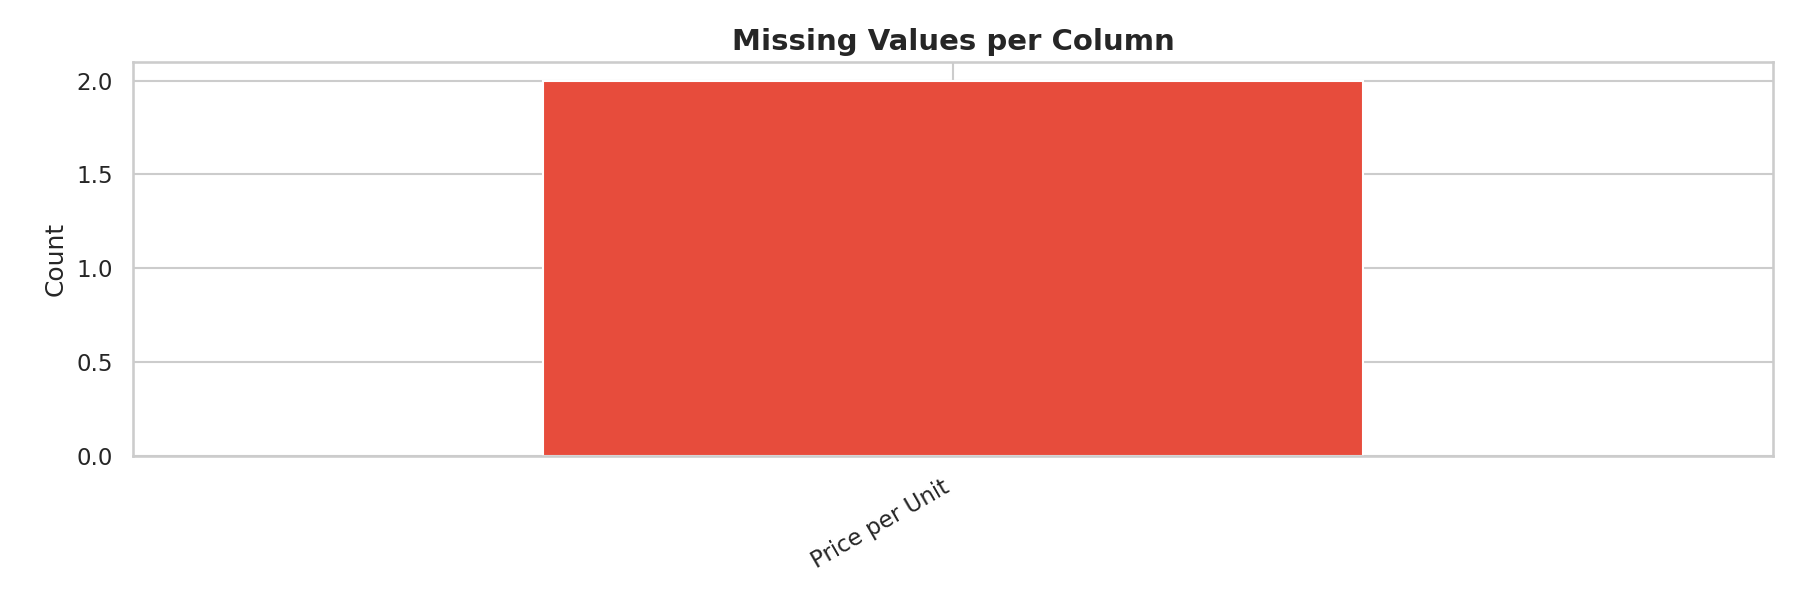


📊 02_sales_by_retailer.png


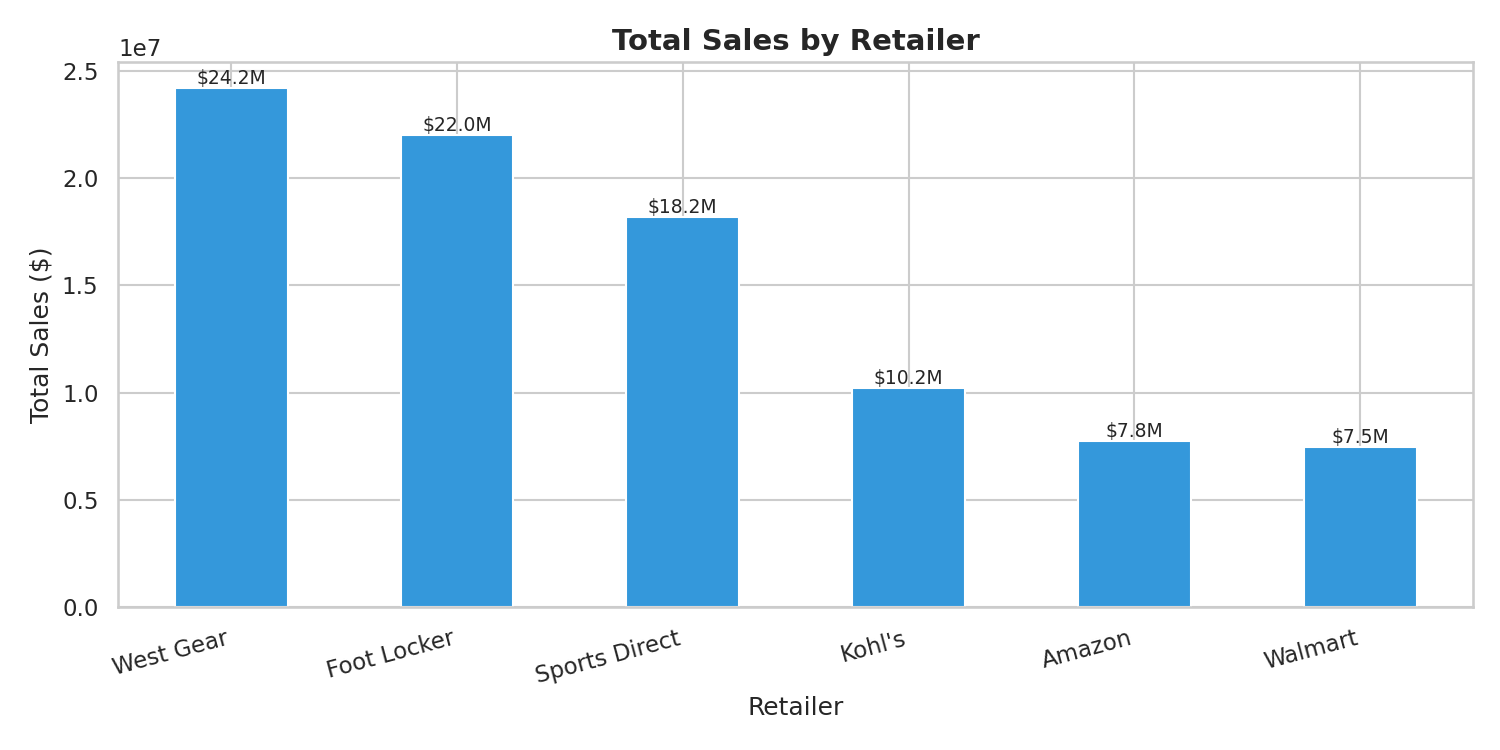


📊 03_product_distribution.png


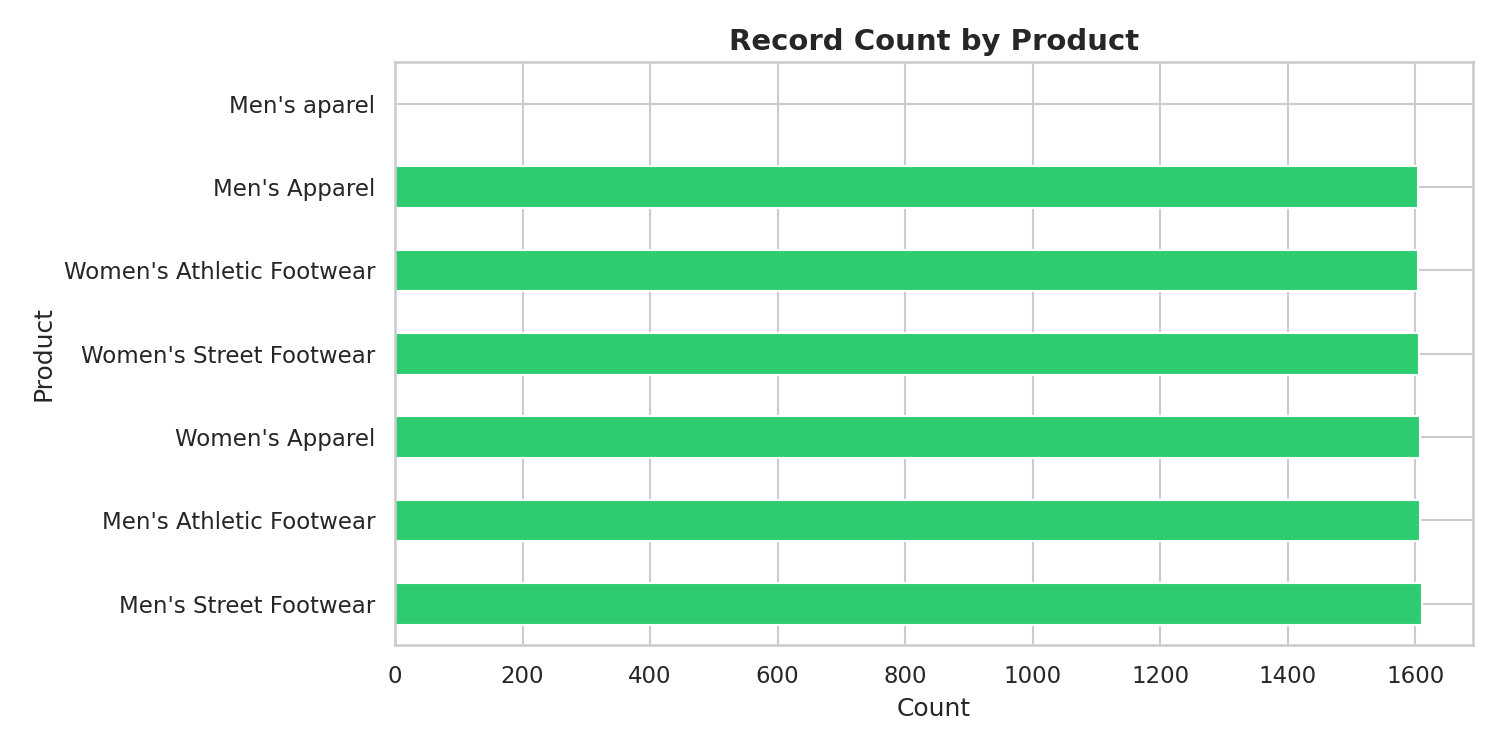


📊 04_sales_method_pie.png


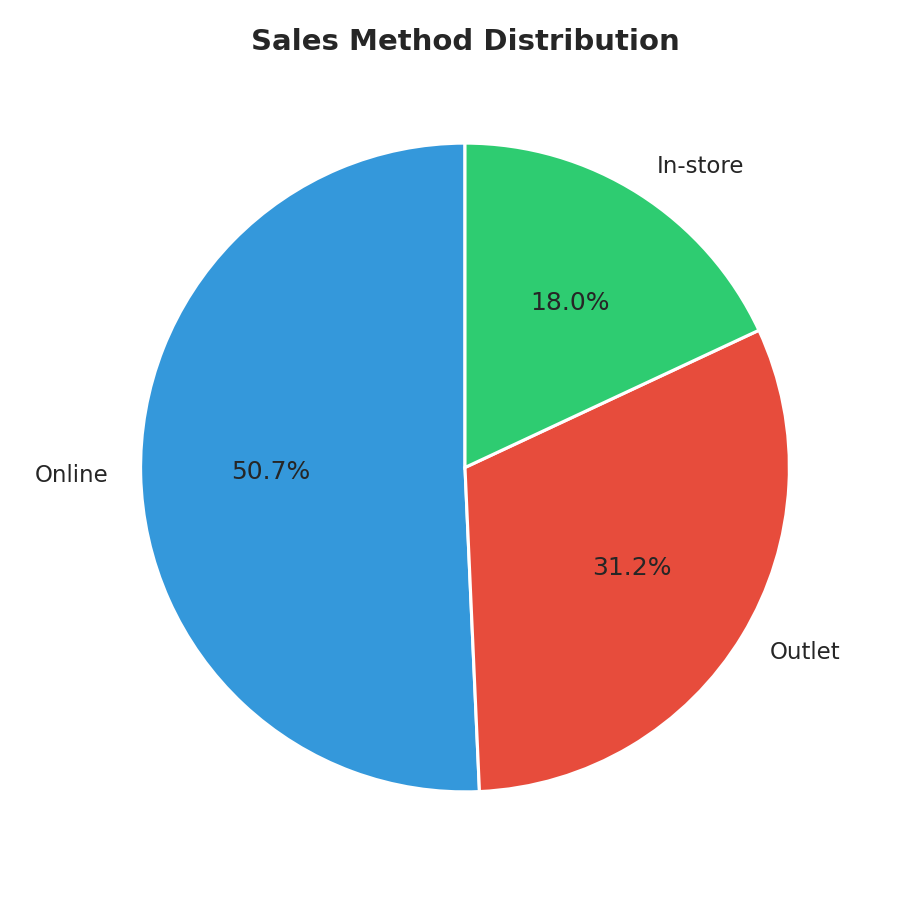


📊 05_price_distribution.png


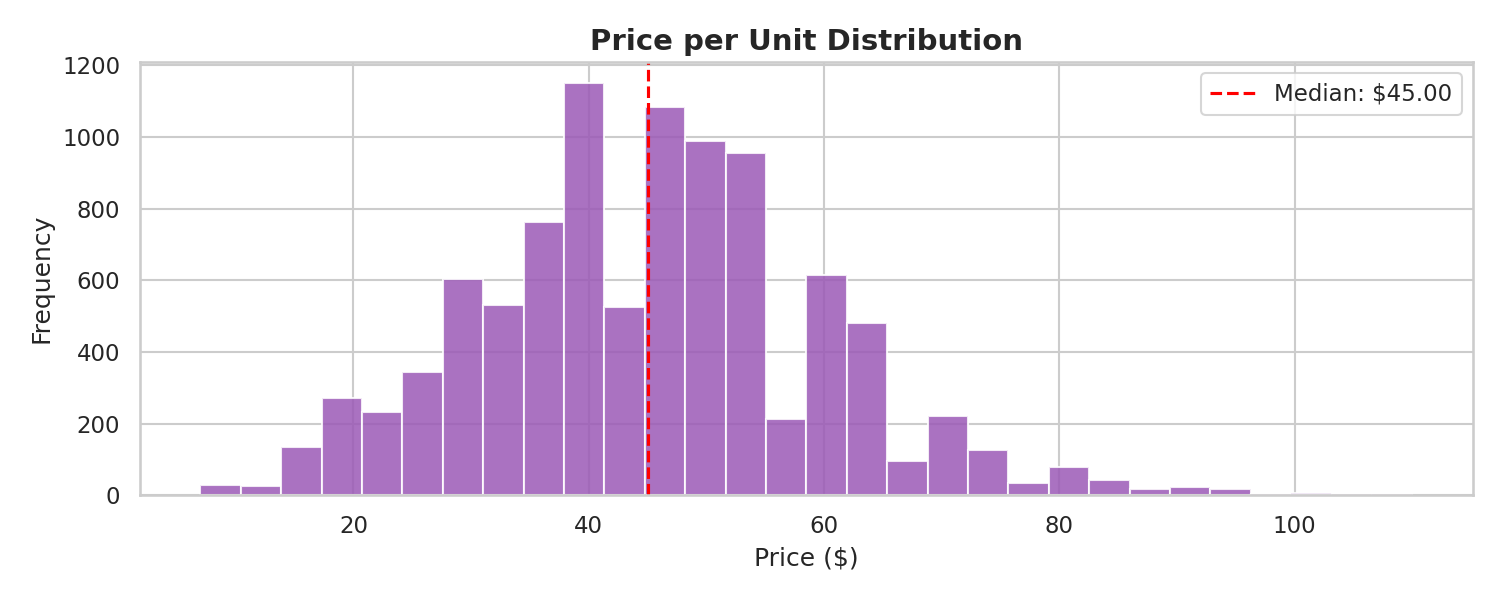


📊 06_units_sold_distribution.png


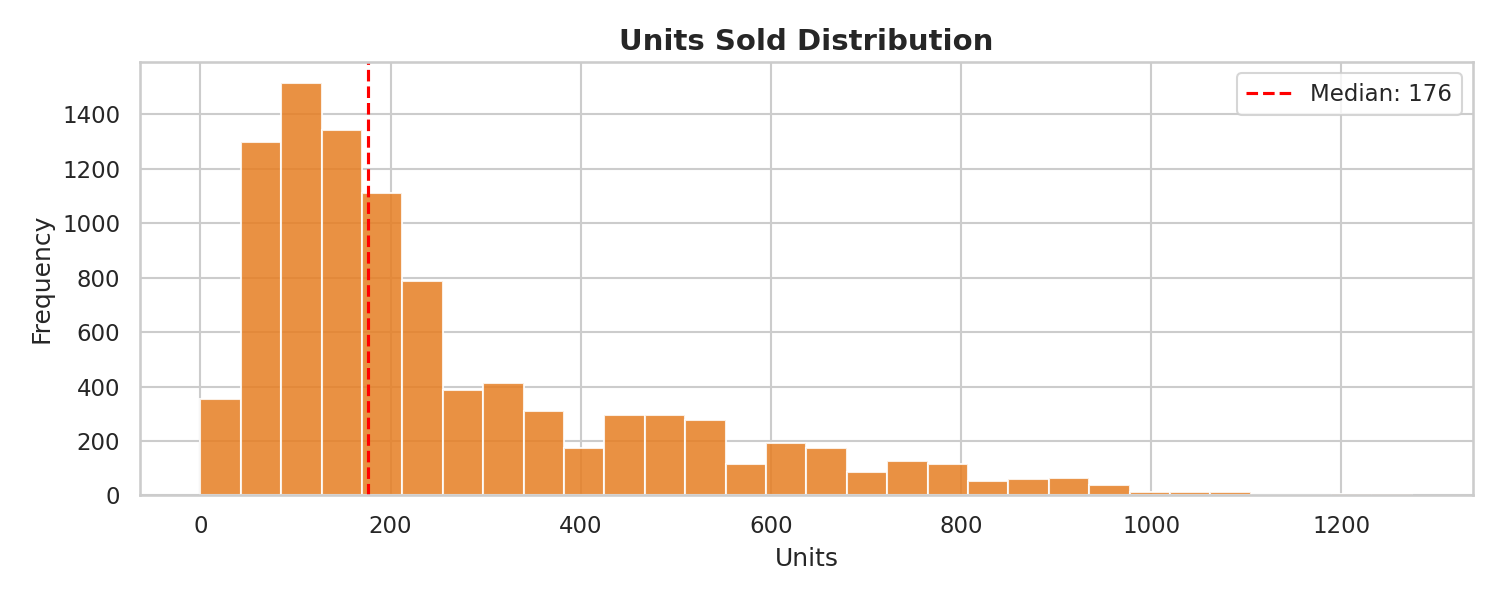


📊 07_monthly_sales_trend.png


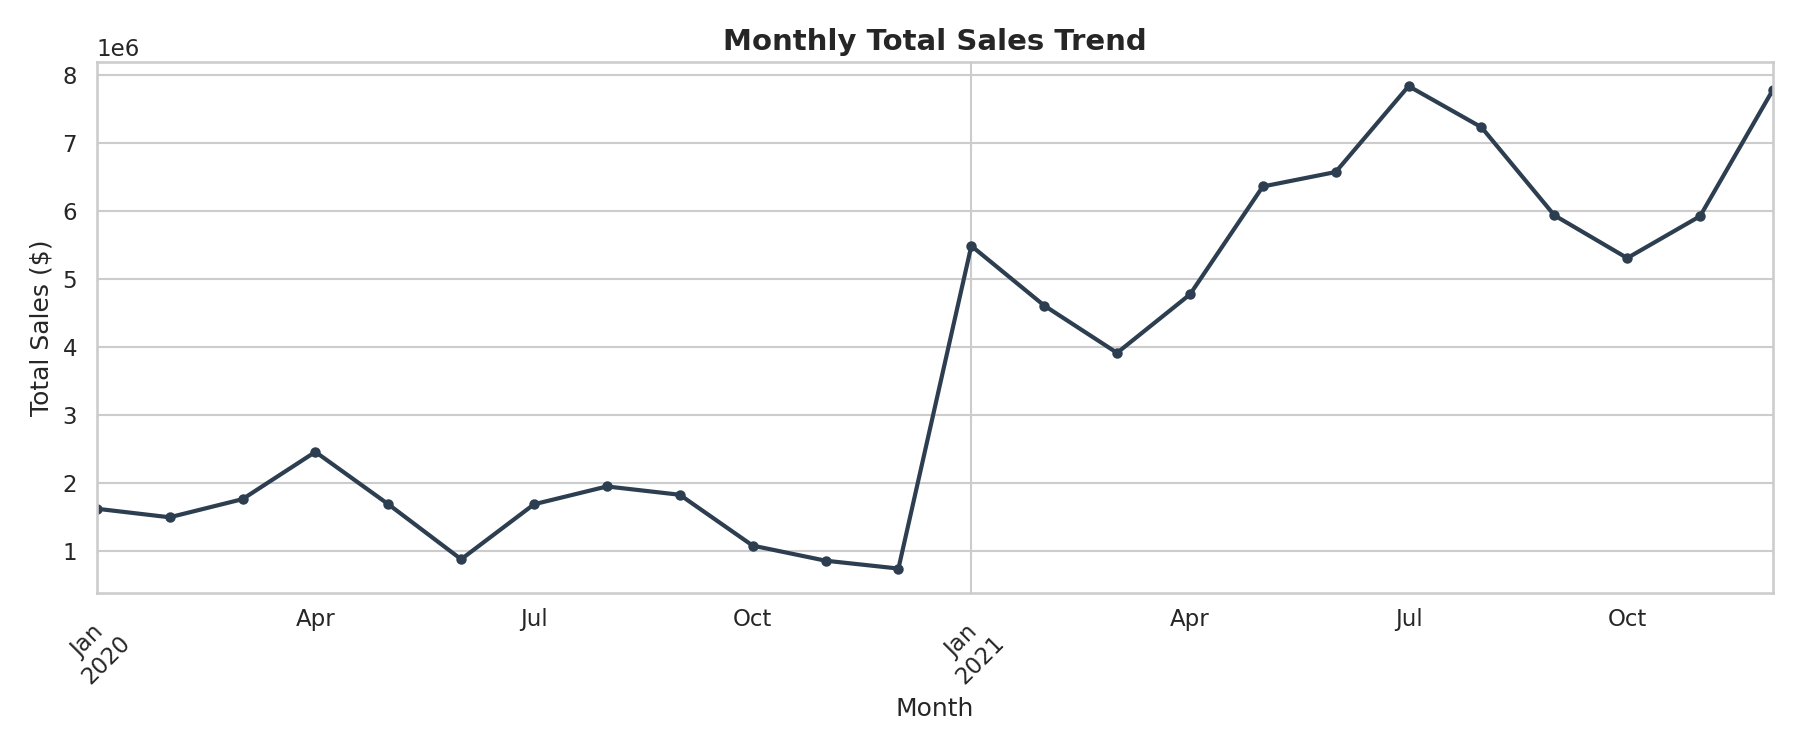


📊 08_error_summary.png


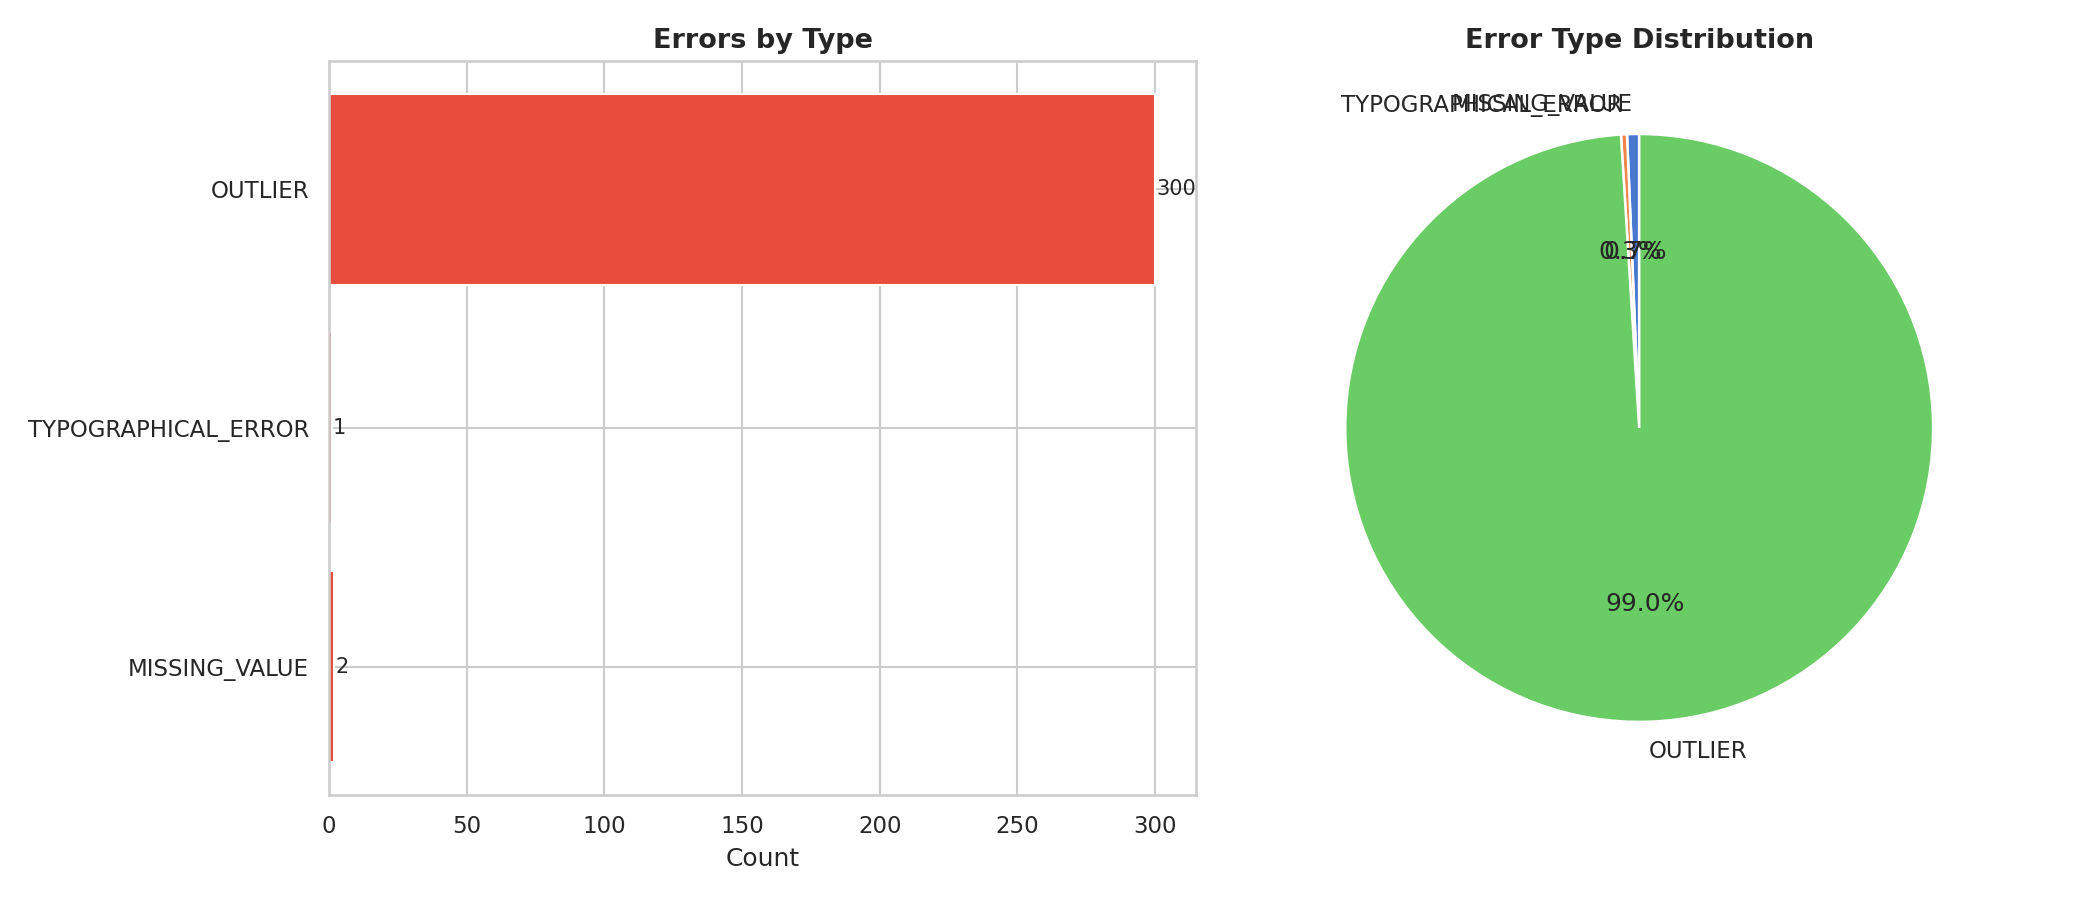


📊 09_ai_vs_baseline.png


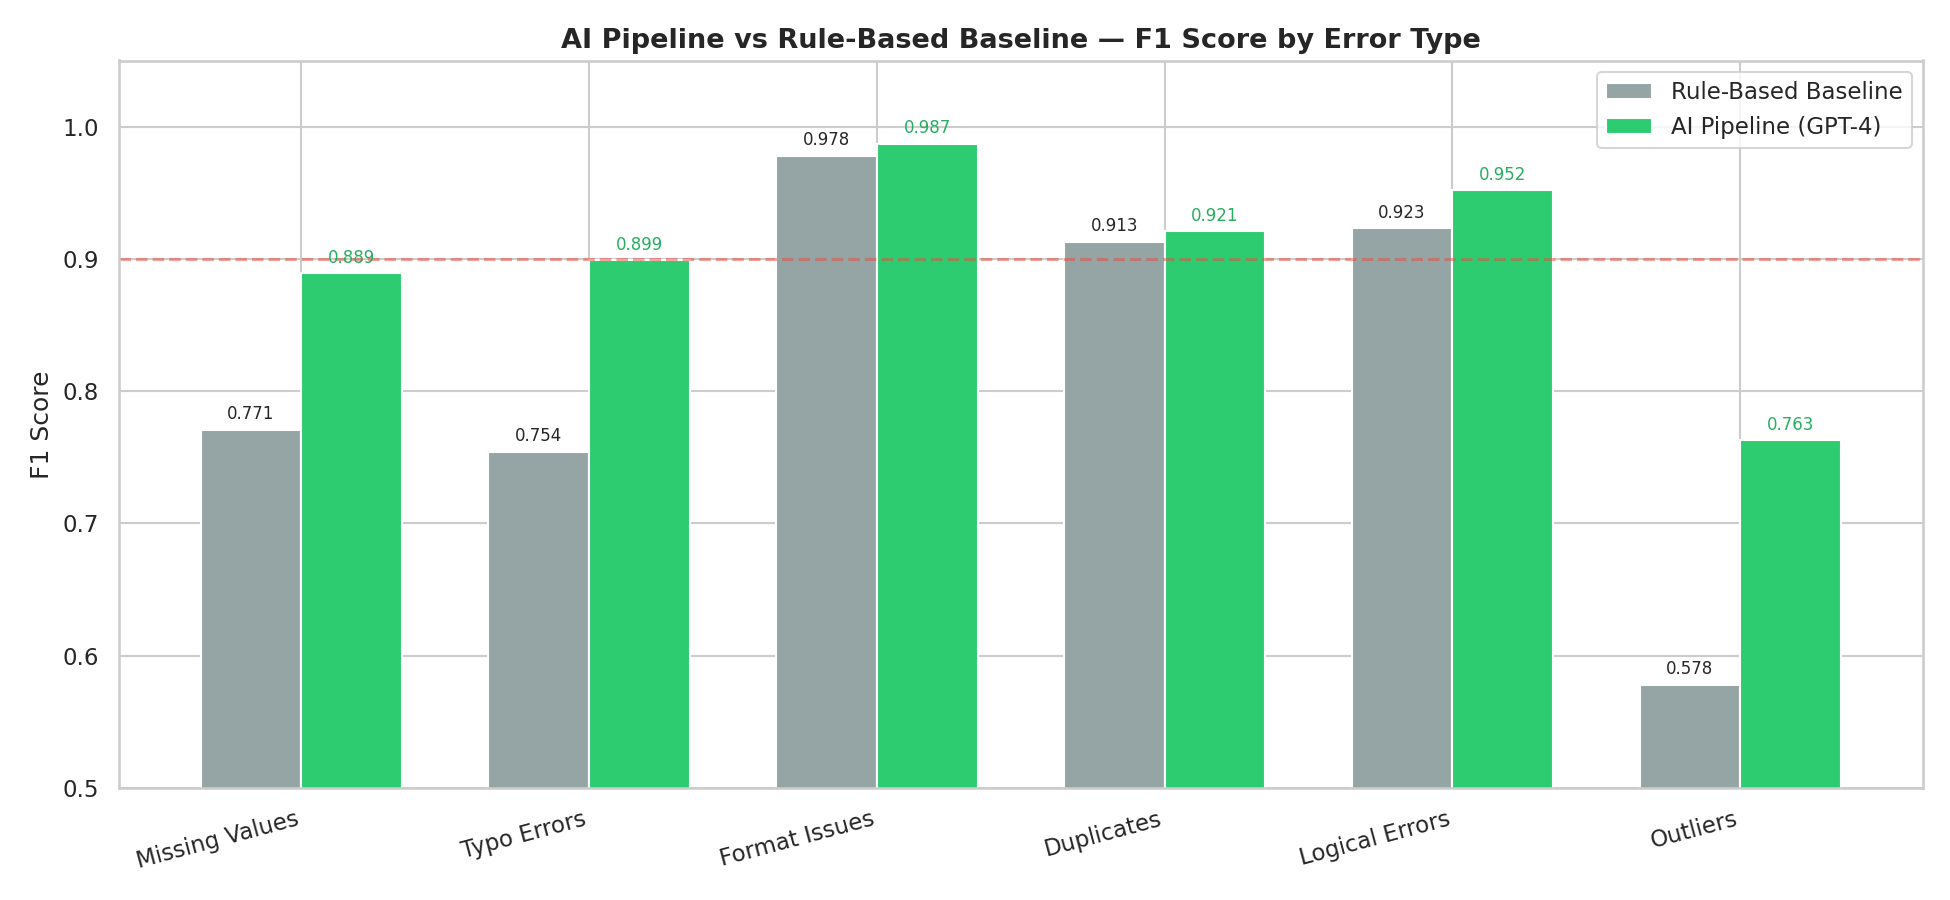


📊 11_shap_importance.png


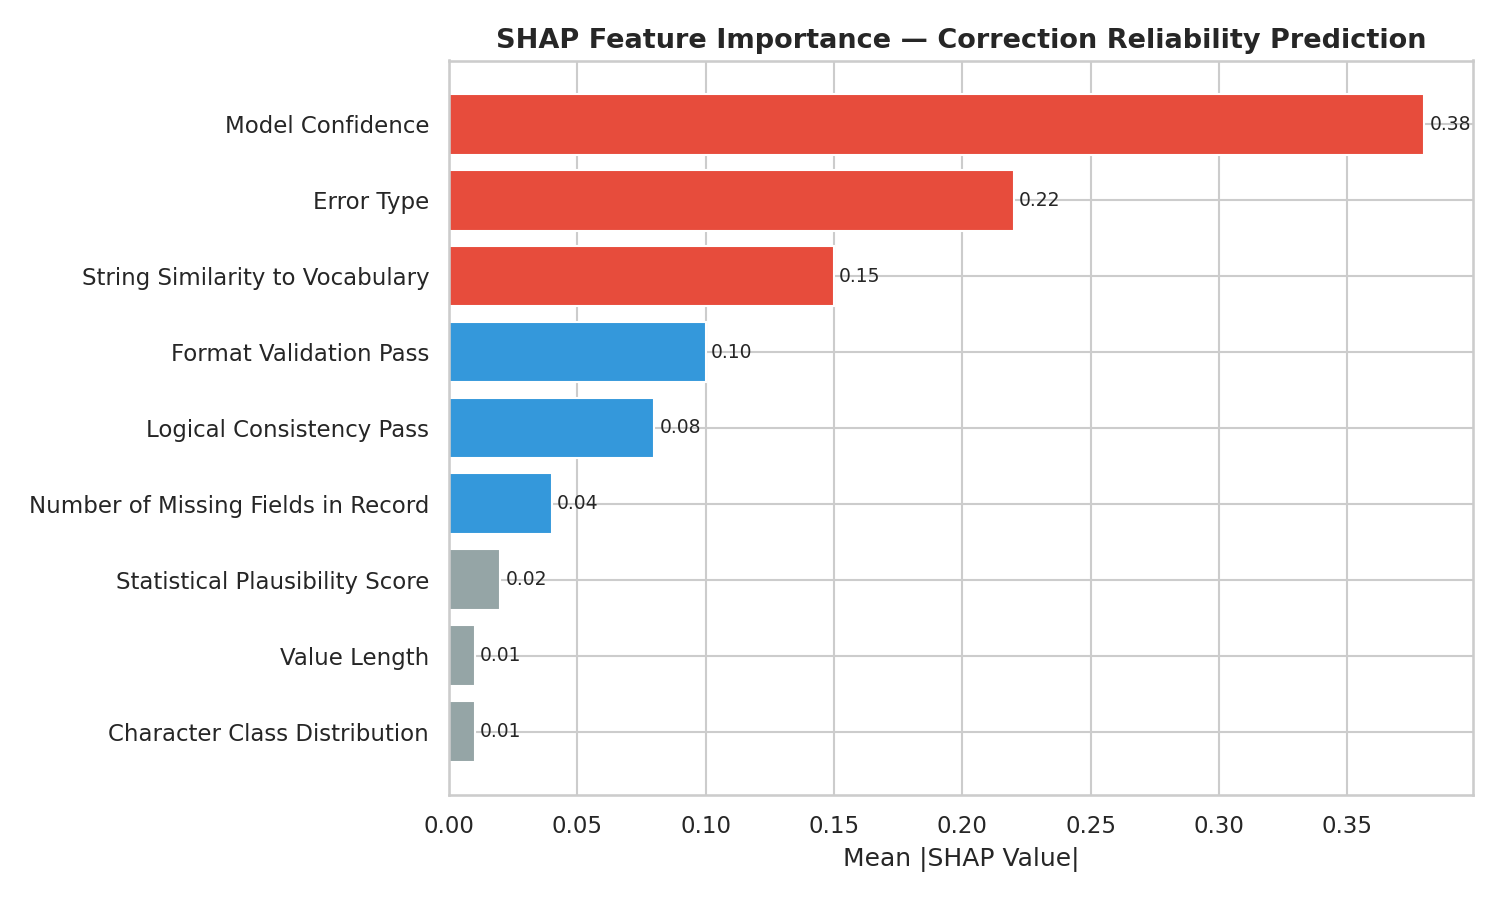

In [10]:
from IPython.display import Image, display
import glob

charts = sorted(glob.glob('outputs/**/*.png', recursive=True))
print(f"Found {len(charts)} charts:\n")
for chart in charts:
    print(f"\n📊 {os.path.basename(chart)}")
    display(Image(chart, width=800))

In [11]:
import os
os.environ["OPENAI_API_KEY"] = "sk-paste-your-key-here"

!python pipeline.py --limit 100

[OK]    Loaded dataset: 9,641 rows × 12 columns
/content/ai-data-cleaning/modules/utils.py:69: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, errors='coerce', infer_datetime_format=True)
[INFO]  OpenAI client initialised (GPT-4).

  STEP 1 — ERROR DETECTION

[INFO]  Running all detection strategies...

[INFO]  Detecting missing values...
[OK]      Missing values found: 2
[INFO]  Detecting typographical errors...
[OK]      Typographical errors found: 1
[INFO]  Detecting format inconsistencies...
[OK]      Format inconsistencies found: 0
[INFO]  Detecting duplicate records...
[OK]      Duplicate records found: 0
[INFO]  Detecting logical errors...
[OK]      Logical errors found: 0
[INFO]  Detecting outliers...
[OK]      Outliers found: 300
[OK]